# Real-ESRGAN Anime 6B 推理脚本 (Inference)

本 Notebook 集成 Real-ESRGAN 的 **动漫模型**：`RealESRGAN_x4plus_anime_6B.pth`（4× 放大）。

- **模型说明**见官方文档：[Anime Model](https://github.com/xinntao/Real-ESRGAN/blob/master/docs/anime_model.md)
- **权重下载**（官方 release）：`RealESRGAN_x4plus_anime_6B.pth`
- **放置位置**：`pretrained_models/RealESRGAN_x4plus_anime_6B.pth`
- **输入目录**：`dataset/lowres_4x/original`
- **输出目录**：`results/RealESRGAN_anime_6B_4x_inference`

> 说明：这里直接用你仓库里的 `APISR_tools/architecture/rrdb.py`（RRDBNet, scale=4, num_block=6）来加载该权重，并提供 tile 推理避免 OOM。

In [1]:
import os
import sys
import glob
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch

# 将本地的 APISR_tools 目录添加到系统路径
apisr_tools_path = os.path.abspath('APISR_tools')
if apisr_tools_path not in sys.path:
    sys.path.append(apisr_tools_path)

from architecture.rrdb import RRDBNet

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch: 2.10.0+cu128
CUDA available: True


In [2]:
# ==========================================
# 1) 配置参数
# ==========================================
UPSCALE_MODE = '4x'
SCALE = 4

# Real-ESRGAN anime 6B
MODEL_NAME = 'RealESRGAN_x4plus_anime_6B.pth'
MODEL_PATH = os.path.join('pretrained_models', MODEL_NAME)

# 数据路径
LR_DIR = 'dataset/lowres_4x/original'
HR_DIR = 'dataset/highres/original'
OUTPUT_DIR = 'results/RealESRGAN_anime_6B_4x_inference'

# RRDBNet 配置（anime_6B 对应 6 blocks）
NUM_BLOCK = 6
NUM_FEAT = 64
NUM_GROW_CH = 32

# tile 推理（大图建议用）
TILE = 256         # 0 表示不分块；建议 256/384/512
TILE_PAD = 16      # tile 额外 padding，减轻接缝

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('MODEL_PATH:', MODEL_PATH)
print('LR_DIR:', LR_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

Device: cuda
MODEL_PATH: pretrained_models/RealESRGAN_x4plus_anime_6B.pth
LR_DIR: dataset/lowres_4x/original
OUTPUT_DIR: results/RealESRGAN_anime_6B_4x_inference


In [3]:
# ==========================================
# 2) 加载模型权重
# ==========================================
model = RRDBNet(
    3,
    3,
    scale=SCALE,
    num_feat=NUM_FEAT,
    num_block=NUM_BLOCK,
    num_grow_ch=NUM_GROW_CH,
).to(device)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f'未找到权重: {MODEL_PATH}\n'
        '请从官方文档下载并放入 pretrained_models/：\n'
        'https://github.com/xinntao/Real-ESRGAN/blob/master/docs/anime_model.md'
    )

size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f'Weight size: {size_mb:.2f} MB')

ckpt = None
try:
    ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
    # 老版本 torch 无 weights_only
    ckpt = torch.load(MODEL_PATH, map_location=device)
except Exception:
    # 某些权重包含非 tensor 元素时，weights_only 可能失败
    ckpt = torch.load(MODEL_PATH, map_location=device)

# 兼容不同格式
if isinstance(ckpt, dict) and 'params_ema' in ckpt:
    state = ckpt['params_ema']
    print('Loaded: params_ema')
elif isinstance(ckpt, dict) and 'params' in ckpt:
    state = ckpt['params']
    print('Loaded: params')
elif isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    state = ckpt['model_state_dict']
    print('Loaded: model_state_dict')
else:
    state = ckpt
    print('Loaded: raw state_dict')

model.load_state_dict(state, strict=True)
model.eval()
print('模型加载完成。')

Weight size: 17.11 MB
Loaded: params_ema
模型加载完成。


In [4]:
# ==========================================
# 3) 推理函数（支持 tile / overlap 融合，减少接缝）
# ==========================================

def _img_to_tensor_bgr(img_bgr: np.ndarray) -> torch.Tensor:
    """BGR uint8 -> RGB float tensor [1,3,H,W] in [0,1]."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(img_rgb.transpose(2, 0, 1)).float() / 255.0
    return t.unsqueeze(0)


def _tensor_to_img_bgr(t: torch.Tensor) -> np.ndarray:
    """RGB float tensor [1,3,H,W] -> BGR uint8."""
    t = t.detach().float().clamp(0, 1).cpu().squeeze(0)
    img_rgb = (t.numpy().transpose(1, 2, 0) * 255.0).round().astype(np.uint8)
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)


def _infer_tile(x: torch.Tensor, tile: int, tile_pad: int) -> torch.Tensor:
    """Tile inference with simple averaging blend."""
    if tile <= 0:
        with torch.no_grad():
            return model(x)

    b, c, h, w = x.shape
    out = torch.zeros((b, 3, h * SCALE, w * SCALE), device='cpu', dtype=torch.float32)
    weight = torch.zeros((b, 1, h * SCALE, w * SCALE), device='cpu', dtype=torch.float32)

    for y in range(0, h, tile):
        for x0 in range(0, w, tile):
            y1 = min(y + tile, h)
            x1 = min(x0 + tile, w)

            y0_pad = max(y - tile_pad, 0)
            x0_pad = max(x0 - tile_pad, 0)
            y1_pad = min(y1 + tile_pad, h)
            x1_pad = min(x1 + tile_pad, w)

            patch = x[:, :, y0_pad:y1_pad, x0_pad:x1_pad].to(device)
            with torch.no_grad():
                pred = model(patch).detach().float().cpu()

            # crop away the padding region on SR space
            top = (y - y0_pad) * SCALE
            left = (x0 - x0_pad) * SCALE
            bottom = top + (y1 - y) * SCALE
            right = left + (x1 - x0) * SCALE
            pred_c = pred[:, :, top:bottom, left:right]

            oy0 = y * SCALE
            ox0 = x0 * SCALE
            oy1 = y1 * SCALE
            ox1 = x1 * SCALE

            out[:, :, oy0:oy1, ox0:ox1] += pred_c
            weight[:, :, oy0:oy1, ox0:ox1] += 1.0

    out = out / weight.clamp(min=1e-6)
    return out


def infer_one(lr_path: str, save_dir: str | None = None, show: bool = False):
    img = cv2.imread(lr_path, cv2.IMREAD_COLOR)
    if img is None:
        print('无法读取:', lr_path)
        return None

    x = _img_to_tensor_bgr(img).to(device)

    # autocast only on cuda
    with torch.no_grad():
        if device.type == 'cuda':
            with torch.amp.autocast('cuda', enabled=True):
                sr = _infer_tile(x, TILE, TILE_PAD)
        else:
            sr = _infer_tile(x, TILE, TILE_PAD)

    sr_img = _tensor_to_img_bgr(sr)

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(lr_path))[0]
        out_path = os.path.join(save_dir, f'{base}.png')
        cv2.imwrite(out_path, sr_img)

    if show:
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title('LR')
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB))
        plt.title('SR (RealESRGAN anime 6B)')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return sr_img

Found 434 LR images
Saving to: results/RealESRGAN_anime_6B_4x_inference


RealESRGAN anime 6B:  24%|██▍       | 106/434 [01:34<06:00,  1.10s/it]

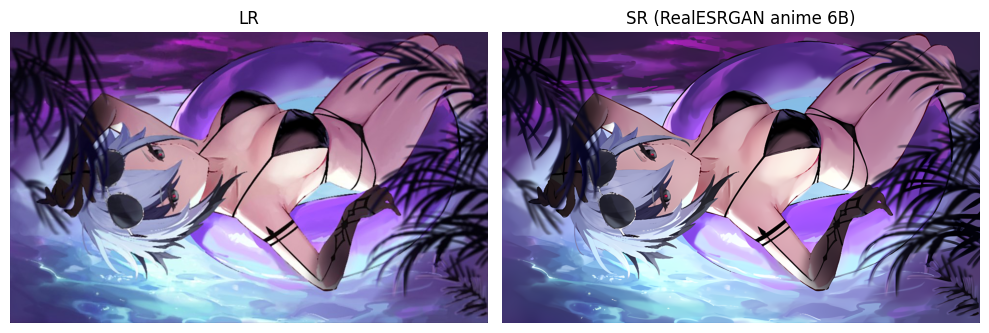

RealESRGAN anime 6B:  57%|█████▋    | 246/434 [03:05<01:58,  1.59it/s]

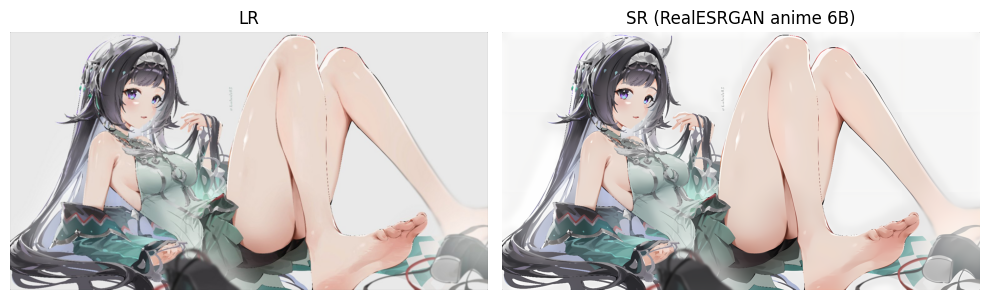

RealESRGAN anime 6B:  91%|█████████ | 394/434 [04:19<00:15,  2.59it/s]

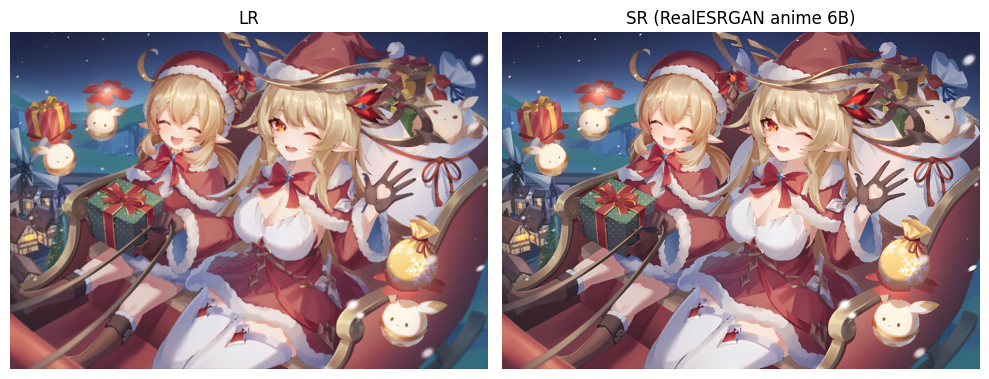

RealESRGAN anime 6B: 100%|██████████| 434/434 [04:39<00:00,  1.55it/s]

批量推理完成。


In [5]:
# ==========================================
# 4) 批量推理
# ==========================================
from tqdm import tqdm

lr_paths = sorted(glob.glob(os.path.join(LR_DIR, '*.*')))
if not lr_paths:
    raise FileNotFoundError(f'未找到 LR 图像，请检查: {LR_DIR}')

print(f'Found {len(lr_paths)} LR images')
print('Saving to:', OUTPUT_DIR)

num_vis = min(3, len(lr_paths))
vis_indices = set(random.sample(range(len(lr_paths)), num_vis))

for idx, p in enumerate(tqdm(lr_paths, desc='RealESRGAN anime 6B')):
    show = idx in vis_indices
    infer_one(p, save_dir=OUTPUT_DIR, show=show)

print('批量推理完成。')

In [6]:
# ==========================================
# 5) 可选：无参考质量评估 (NIQE, MANIQA, CLIPIQA)
# ==========================================
# 需要: pip install pyiqa
try:
    import pyiqa
except ImportError:
    print('未安装 pyiqa，跳过评估。可执行: pip install pyiqa')
else:
    sr_paths = sorted(glob.glob(os.path.join(OUTPUT_DIR, '*.*')))
    if not sr_paths:
        raise FileNotFoundError('未找到输出图像，请先运行上面的批量推理。')

    niqe_metric = pyiqa.create_metric('niqe', device=device)
    maniqa_metric = pyiqa.create_metric('maniqa', device=device)
    clipiqa_metric = pyiqa.create_metric('clipiqa', device=device)

    niqe_scores = []
    maniqa_scores = []
    clipiqa_scores = []

    for p in tqdm(sr_paths, desc='Evaluating'):
        niqe_scores.append(niqe_metric(p).item())
        maniqa_scores.append(maniqa_metric(p).item())
        clipiqa_scores.append(clipiqa_metric(p).item())

    print('\n========================================')
    print('Real-ESRGAN anime 6B (No-Reference IQA)')
    print('========================================')
    print('Average NIQE   (↓):', float(np.mean(niqe_scores)))
    print('Average MANIQA (↑):', float(np.mean(maniqa_scores)))
    print('Average CLIPIQA(↑):', float(np.mean(clipiqa_scores)))
    print('========================================')

/home/shunyu/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/shunyu/miniconda3/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading pretrained model MANIQA from /home/shunyu/.cache/torch/hub/pyiqa/ckpt_koniq10k.pt


Evaluating: 100%|██████████| 434/434 [5:52:20<00:00, 48.71s/it]     


Real-ESRGAN anime 6B (No-Reference IQA)
Average NIQE   (↓): 6.69014083347963
Average MANIQA (↑): 0.4554109693878257
Average CLIPIQA(↑): 0.5670337399579413
